In [2]:
import pandas as pd           # For loading and working with data (like Excel in Python)
import numpy as np            # For math operations
import matplotlib.pyplot as plt  # For drawing charts

# Load the Dataset

In [3]:
# Load the CSV file
df = pd.read_csv('annual_gold_rate.csv')

print(f"✅ Dataset loaded! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()   # Shows first 5 rows

✅ Dataset loaded! Rows: 44, Columns: 7


,Date,USD,EUR,GBP,INR,AED,CNY
0,1978,193.44,124.73580,100.65449,NaN,NaN,NaN
1,1979,304.68,185.06142,143.09014,2481.90512,1163.93597,NaN
2,1980,614.50,378.19461,263.80259,4831.74943,2278.36795,NaN
3,1981,459.26,360.90588,227.01948,3966.64790,1691.03194,NaN
4,1982,375.30,345.59742,215.53232,3553.62680,1378.72895,NaN


# Data Summary

In [4]:
# Basic info — column names, data types, non-empty counts
print("=" * 50)
print("📋 DATASET INFO")
print("=" * 50)
df.info()

# Statistical summary — average, min, max, etc.
print("\n" + "=" * 50)
print("📈 STATISTICAL SUMMARY")
print("=" * 50)
df.describe()

📋 DATASET INFO
<class 'pandas.DataFrame'>
RangeIndex: 44 entries, 0 to 43
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    44 non-null     int64  
 1   USD     44 non-null     float64
 2   EUR     44 non-null     float64
 3   GBP     44 non-null     float64
 4   INR     43 non-null     float64
 5   AED     43 non-null     float64
 6   CNY     37 non-null     float64
dtypes: float64(6), int64(1)
memory usage: 2.5 KB

📈 STATISTICAL SUMMARY


,Date,USD,EUR,GBP,INR,AED,CNY
count,44.000000,44.000000,44.000000,44.000000,43.000000,43.000000,37.000000
mean,1999.500000,692.055909,571.891313,450.575615,34026.445973,2585.786320,4950.991330
std,12.845233,486.226172,395.398741,357.907845,37476.310663,1783.571654,3377.322124
min,1978.000000,193.440000,124.735800,100.654490,2481.905120,995.506180,926.645180
25%,1988.750000,360.540000,302.387860,215.853185,6423.166690,1327.153290,2243.380520
50%,1999.500000,416.415000,359.622620,249.850690,12788.438900,1557.457900,3306.274890
75%,2010.250000,1176.175000,932.098448,761.273783,64728.547700,4379.206195,8283.158470
max,2021.000000,1798.610000,1549.044710,1378.980990,132967.875100,6606.550460,12205.481970


# Data Type Analysis

In [8]:
print("=" * 50)
print("🔍 DATA TYPE REPORT")
print("=" * 50)

type_report = pd.DataFrame({
    'Column'         : df.columns,
    'Data Type'      : df.dtypes.values,
    'Non-Empty Count': df.notnull().sum().values,
    'Empty Count'    : df.isnull().sum().values,
    'Unique Values'  : df.nunique().values
})

print(type_report.to_string(index=False))

🔍 DATA TYPE REPORT
Column Data Type  Non-Empty Count  Empty Count  Unique Values
  Date     int64               44            0             44
   USD   float64               44            0             44
   EUR   float64               44            0             44
   GBP   float64               44            0             44
   INR   float64               43            1             43
   AED   float64               43            1             43
   CNY   float64               37            7             37


# Missing Value Detection

❗ MISSING VALUE REPORT
      Missing Count  Missing %
Date              0       0.00
USD               0       0.00
EUR               0       0.00
GBP               0       0.00
INR               1       2.27
AED               1       2.27
CNY               7      15.91


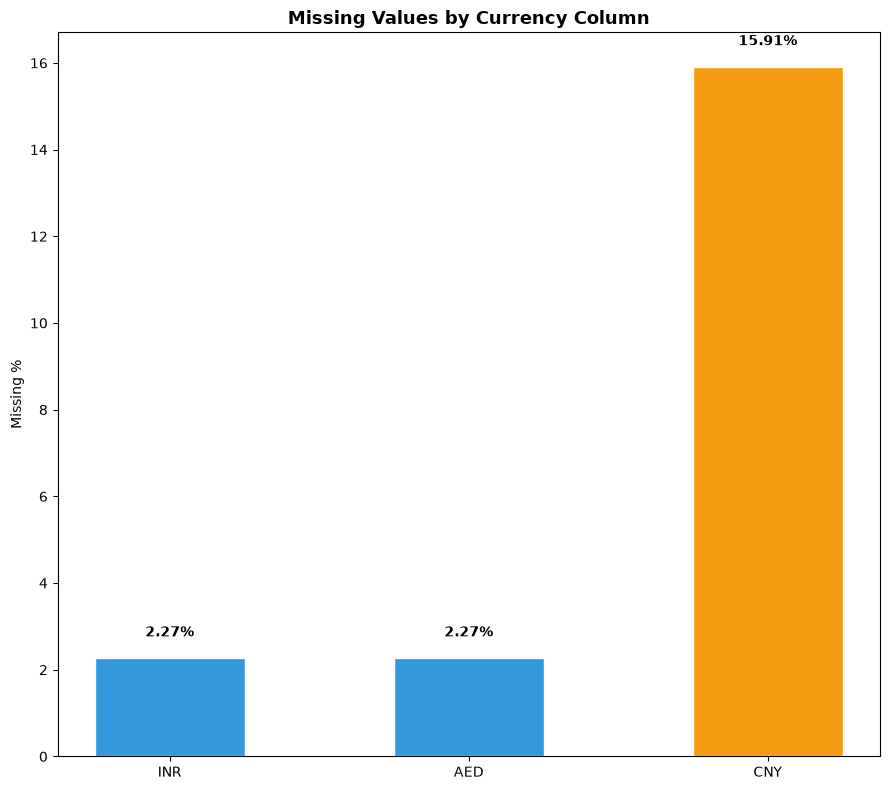

✅ Chart saved.


In [ ]:
# Count missing values per column
missing_count = df.isnull().sum()
missing_pct   = (missing_count / len(df) * 100).round(2)

missing_report = pd.DataFrame({
    'Missing Count': missing_count,
    'Missing %'    : missing_pct
})

print("=" * 50)
print("❗ MISSING VALUE REPORT")
print("=" * 50)
print(missing_report)

# ── Bar Chart for Missing Values ──────────────────────────────
cols_with_missing = missing_report[missing_report['Missing Count'] > 0]

fig, ax = plt.subplots(figsize=(9, 8))
colors = ['#e74c3c' if v > 30 else '#f39c12' if v > 10 else '#3498db'
          for v in cols_with_missing['Missing %']]

bars = ax.bar(cols_with_missing.index, cols_with_missing['Missing %'],
              color=colors, edgecolor='white', width=0.5)

for bar, val in zip(bars, cols_with_missing['Missing %']):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
            f'{val}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel("Missing %")
ax.set_title("Missing Values by Currency Column", fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('missing_values.png', dpi=150)
plt.show()
# print("✅ Chart saved.")

# Visualize the Data

 Line Chart: Gold Price Over the Years (USD)

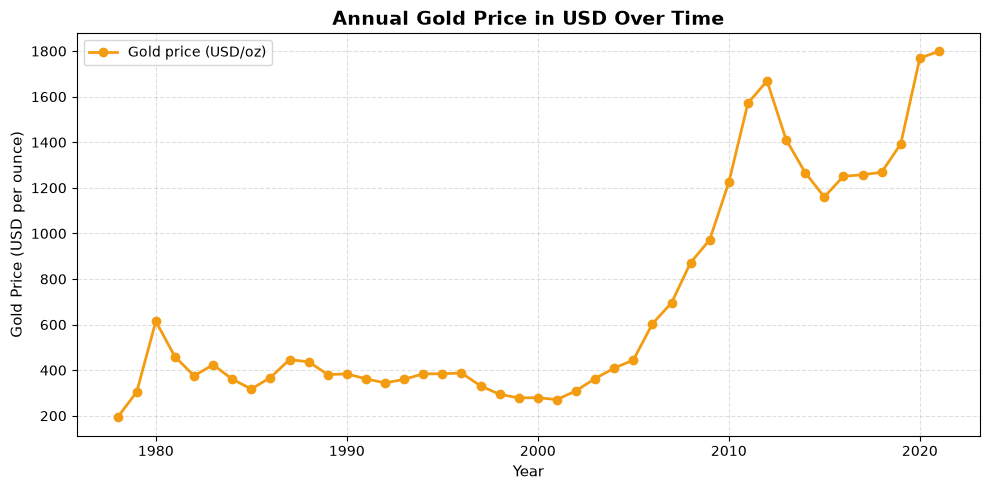

✅ Gold price trend chart saved.


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(
    df['Date'],
    df['USD'],
    marker='o',
    linestyle='-',
    color='#f39c12',
    linewidth=2,
    label='Gold price (USD/oz)'
)

# ✅ This is the line you were starting with: ax.la...
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Gold Price (USD per ounce)", fontsize=11)
ax.set_title("Annual Gold Price in USD Over Time", fontsize=14, fontweight='bold')

ax.grid(True, which='both', linestyle='--', alpha=0.4)
ax.legend()

plt.tight_layout()
# plt.savefig("gold_price_trend_usd.png", dpi=150)
plt.show()
# print("✅ Gold price trend chart saved.")

Line Chart: All Currencies Together

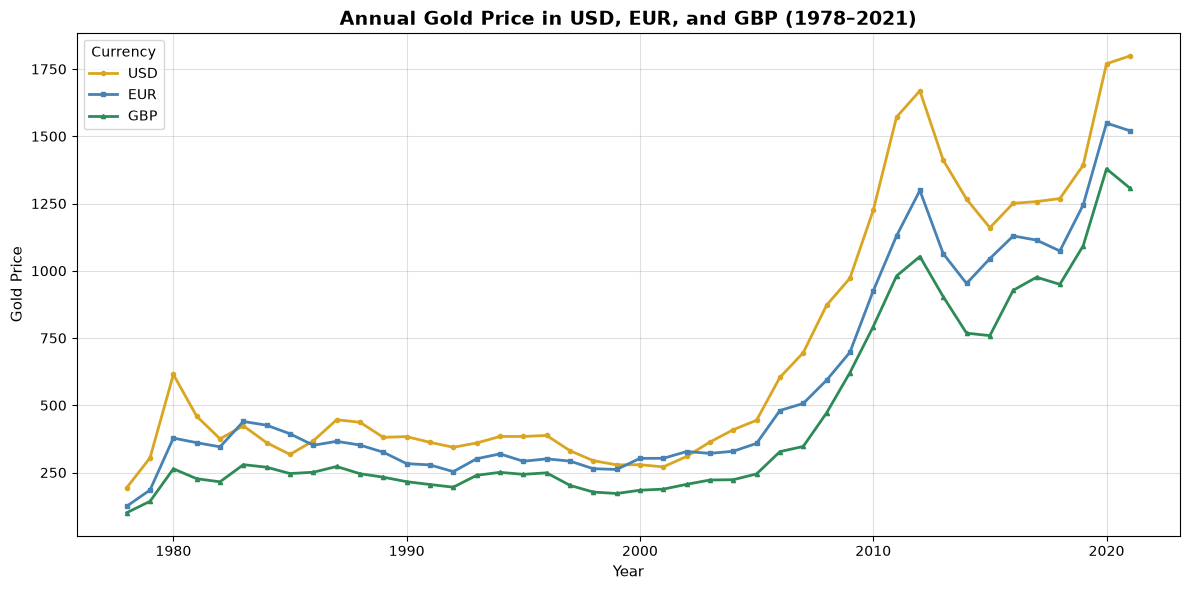

✅ Saved: gold_currency_comparison.png


In [ ]:
fig, ax = plt.subplots(figsize=(12, 6))

# Plot each currency as a separate line
ax.plot(
    df['Date'], df['USD'],
    color='goldenrod', linewidth=2, marker='o', markersize=3,
    label='USD'
)

ax.plot(
    df['Date'], df['EUR'],
    color='steelblue', linewidth=2, marker='s', markersize=3,
    label='EUR'
)

ax.plot(
    df['Date'], df['GBP'],
    color='seagreen', linewidth=2, marker='^', markersize=3,
    label='GBP'
)

# Titles and labels
ax.set_title("Annual Gold Price in USD, EUR, and GBP (1978–2021)",
             fontsize=14, fontweight='bold')
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Gold Price", fontsize=11)

# Grid, legend, and layout
ax.grid(True, alpha=0.4)
ax.legend(title="Currency")

plt.tight_layout()
# plt.savefig('gold_currency_comparison.png', dpi=150)
plt.show()
# print("✅ Saved: gold_currency_comparison.png")

Bar Chart: Gold Price in INR by Year (Last 10 Years)

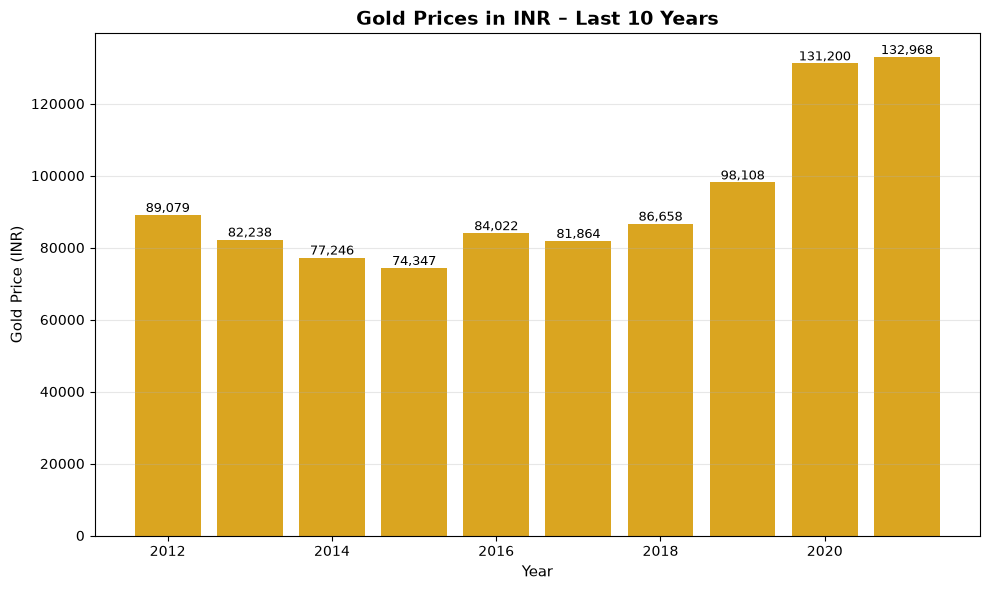

Saved bar chart as gold_inr_last10years_bar.png


In [ ]:
# 1.sorted the data
df_sorted = df.sort_values('Date')

# 2. Select the last 10 years
last_10 = df_sorted.tail(10)

# 3. Create the bar chart
fig, ax = plt.subplots(figsize=(10, 6))

bars = ax.bar(last_10['Date'], last_10['INR'], color='goldenrod')

# 4. Add title and labels
ax.set_title("Gold Prices in INR – Last 10 Years", fontsize=14, fontweight='bold')
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Gold Price (INR)", fontsize=11)

# 5. Add value labels on top of each bar
for bar in bars:
    height = bar.get_height()
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        height,
        f"{height:,.0f}",          # format number; adjust as needed
        ha='center',
        va='bottom',
        fontsize=9,
        rotation=0
    )

# 6. Improve layout and grid
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()

# 7. Save the figure as an image file
# plt.savefig("gold_inr_last10years_bar.png", dpi=150)

# 8. Show the plot
plt.show()
print("Saved bar chart as gold_inr_last10years_bar.png")

Pie Chart: Highest Gold Price Year by Currency

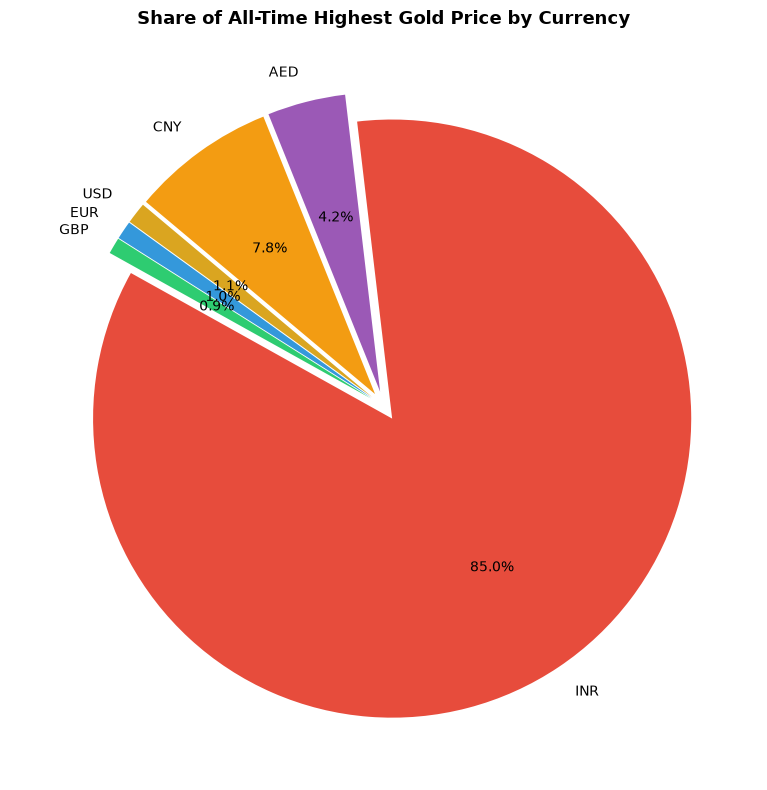

In [ ]:
# Show which year had the max price for each currency
currency_cols_all = ['USD', 'EUR', 'GBP', 'INR', 'AED', 'CNY']
max_prices = [df[col].max() for col in currency_cols_all]

fig, ax = plt.subplots(figsize=(8, 8))
ax.pie(max_prices,
       labels=currency_cols_all,
       autopct='%1.1f%%',
       startangle=140,
       colors=['goldenrod', '#3498db', '#2ecc71', '#e74c3c', '#9b59b6', '#f39c12'],
       explode=[0.05] * len(currency_cols_all))

ax.set_title("Share of All-Time Highest Gold Price by Currency", fontsize=13, fontweight='bold')
plt.tight_layout()
# plt.savefig('gold_pie.png', dpi=150)
plt.show()

# Histogram of Annual Gold Price (USD) 

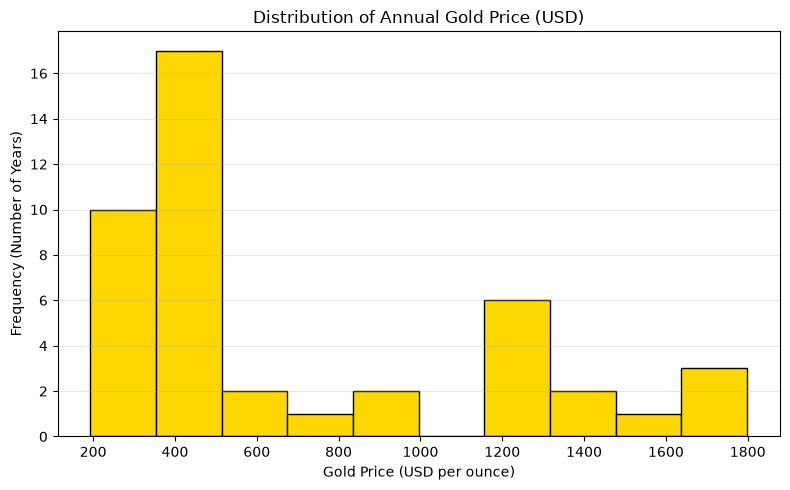

In [36]:
plt.figure(figsize=(8, 5))
plt.hist(df['USD'].dropna(), bins=10, color='gold', edgecolor='black')

plt.title('Distribution of Annual Gold Price (USD)')
plt.xlabel('Gold Price (USD per ounce)')
plt.ylabel('Frequency (Number of Years)')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

Export Report

In [37]:
df.describe().to_csv('summary_statistics.csv')
missing_report.to_csv('missing_values_report.csv')

print("✅ Reports saved successfully!")

✅ Reports saved successfully!


## 📊 Dataset Insights Report — Annual Gold Rate

### 1. Overview
- Years Covered : 1978 to 2021 (44 years)
- Currencies    : USD, EUR, GBP, INR, AED, CNY
- Total Rows    : 44 | Columns: 7

### 2. Missing Values
- INR, AED, CNY : Missing for early years (1978–1984)
  → Data collection for these currencies started later
- USD, EUR, GBP : Complete data throughout

### 3. Key Observations
- Gold in USD was ~$193 in 1978 → rose to ~$1,798 by 2021
- Biggest price jump: 2008–2012 (Global Financial Crisis period)
- INR price of gold went from ~₹2,481 (1979) to ₹1,32,967 (2021)
- All currencies show a consistent upward trend after 2005

### 4. Charts Created
- Line Chart  : USD gold price trend over 44 years
- Multi-Line  : USD vs EUR vs GBP comparison
- Bar Chart   : INR gold prices (last 10 years)
- Histogram   : Distribution of USD prices
- Pie Chart   : Max price share by currency